In [2]:
import numpy as np
import pandas as pd
import pickle
import shap
import matplotlib.pyplot as plt

d:\AI Credit Risk Scoring + Explainable AI + LLM Layer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open("../models/xgboost_model.pkl","rb") as f:
    model=pickle.load(f)

with open("../models/scaler.pkl","rb") as f:
    scalar = pickle.load(f)

with open("../models/feature_names.pkl","rb") as f:
    features_name=pickle.load(f)

with open("../models/threshold.pkl","rb") as f:
    threshold=pickle.load(f)

print("Artifacts Loaded:")
print(f"Model: XGBoost")
print(f" Features: {len(features_name)}")
print(f"Threshold : {threshold}")

Artifacts Loaded:
Model: XGBoost
 Features: 44
Threshold : 0.4


In [6]:
df=pd.read_csv("../data/featured_data/featured_data.csv")

In [7]:
X=df.drop(columns=["Target"])
y=df['Target']

In [8]:
np.random.seed(42)
sample_idx=np.random.choice(len(X), size=5000, replace=False)
X_sample= X.iloc[sample_idx]
y_sample= y.iloc[sample_idx]


In [9]:
X_sample_scaled=scalar.transform(X_sample)

print(f"Full dataset: {X.shape}")
print(f"Sample size: {X_sample.shape}")

Full dataset: (1344015, 44)
Sample size: (5000, 44)


In [10]:
explainer=shap.TreeExplainer(model)

print("Calculating SHAP values....")
shap_values=explainer.shap_values(X_sample_scaled)

print("Done")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value (avg prediction) : {explainer.expected_value: .4f}")

Calculating SHAP values....
Done
SHAP values shape: (5000, 44)
Base value (avg prediction) : -0.0006


C:\Users\lenovo\AppData\Local\Temp\ipykernel_89272\2975569914.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample_scaled, feature_names=features_name, show=False)


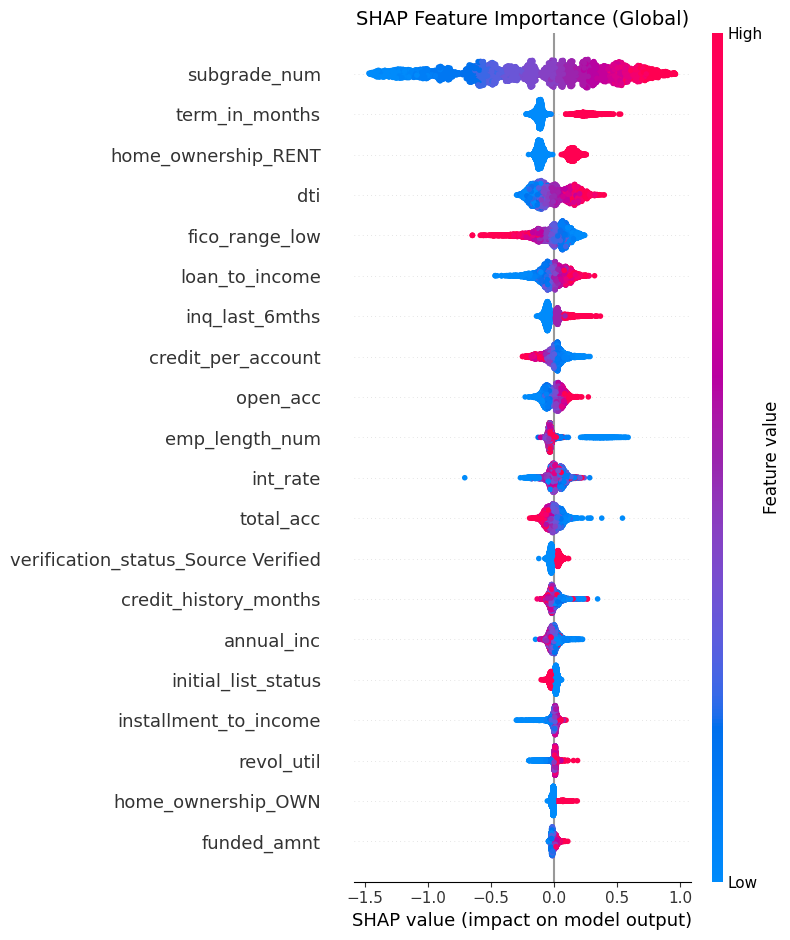

In [12]:
# GLOBAL FEATURE IMPORTANCE - Which features matter most overall?
plt.figure(figsize=(10, 12))
shap.summary_plot(shap_values, X_sample_scaled, feature_names=features_name, show=False)
plt.title("SHAP Feature Importance (Global)", fontsize=14)
plt.tight_layout()
plt.show()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_89272\2552052563.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample_scaled, feature_names=features_name,


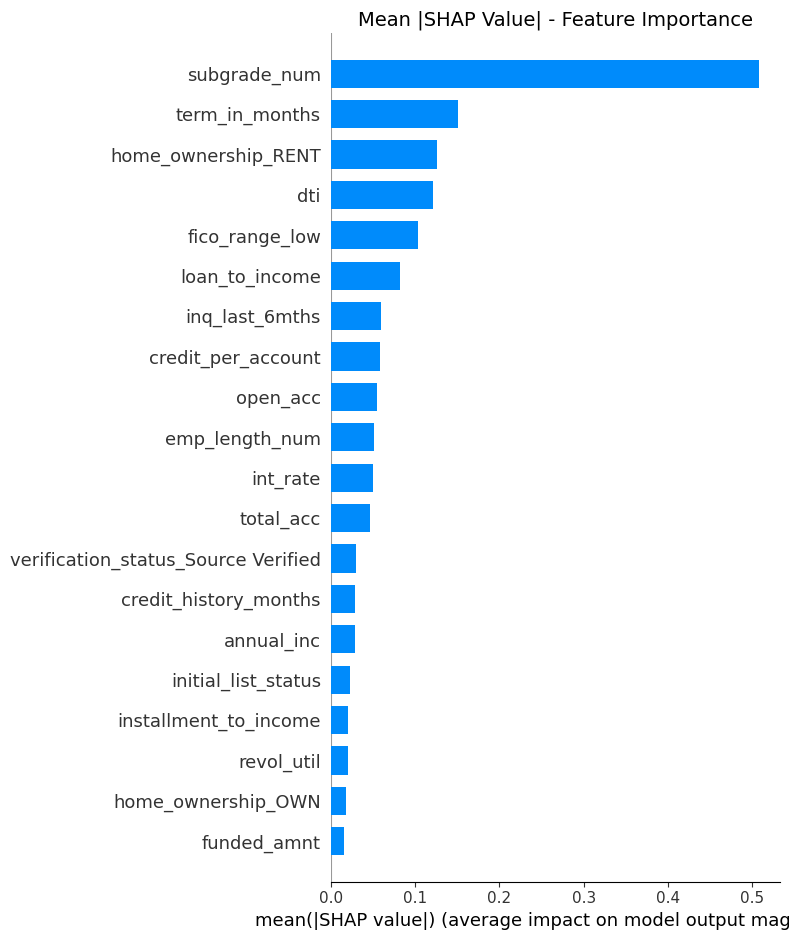

In [13]:
# MEAN ABSOLUTE SHAP VALUES (Simpler bar chart)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample_scaled, feature_names=features_name, 
                  plot_type="bar", show=False)
plt.title("Mean |SHAP Value| - Feature Importance", fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
# Get predictions for our sample
proba = model.predict_proba(X_sample_scaled)[:, 1]

# Find examples of high-risk and low-risk
high_risk_idx = np.where(proba > 0.7)[0][0]  # First high-risk case
low_risk_idx = np.where(proba < 0.2)[0][0]   # First low-risk case

print("HIGH RISK Customer:")
print(f"  Index: {high_risk_idx}")
print(f"  Probability: {proba[high_risk_idx]:.2%}")
print(f"  Actual Label: {'Default' if y_sample.iloc[high_risk_idx] == 1 else 'Fully Paid'}")

print("\nLOW RISK Customer:")
print(f"  Index: {low_risk_idx}")
print(f"  Probability: {proba[low_risk_idx]:.2%}")
print(f"  Actual Label: {'Default' if y_sample.iloc[low_risk_idx] == 1 else 'Fully Paid'}")


HIGH RISK Customer:
  Index: 1
  Probability: 78.07%
  Actual Label: Fully Paid

LOW RISK Customer:
  Index: 5
  Probability: 10.12%
  Actual Label: Fully Paid


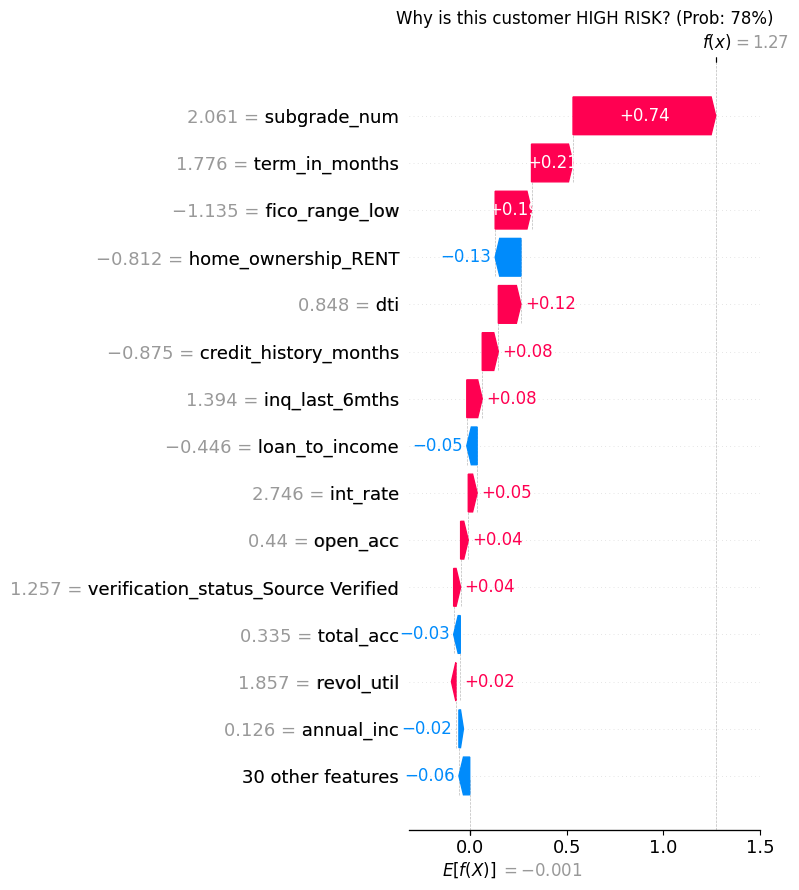

In [15]:
# INDIVIDUAL EXPLANATION - HIGH RISK CUSTOMER
plt.figure(figsize=(10, 8))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_sample_scaled[high_risk_idx],
    feature_names=features_name
), max_display=15, show=False)
plt.title(f"Why is this customer HIGH RISK? (Prob: {proba[high_risk_idx]:.0%})", fontsize=12)
plt.tight_layout()
plt.show()


<Figure size 1000x800 with 0 Axes>

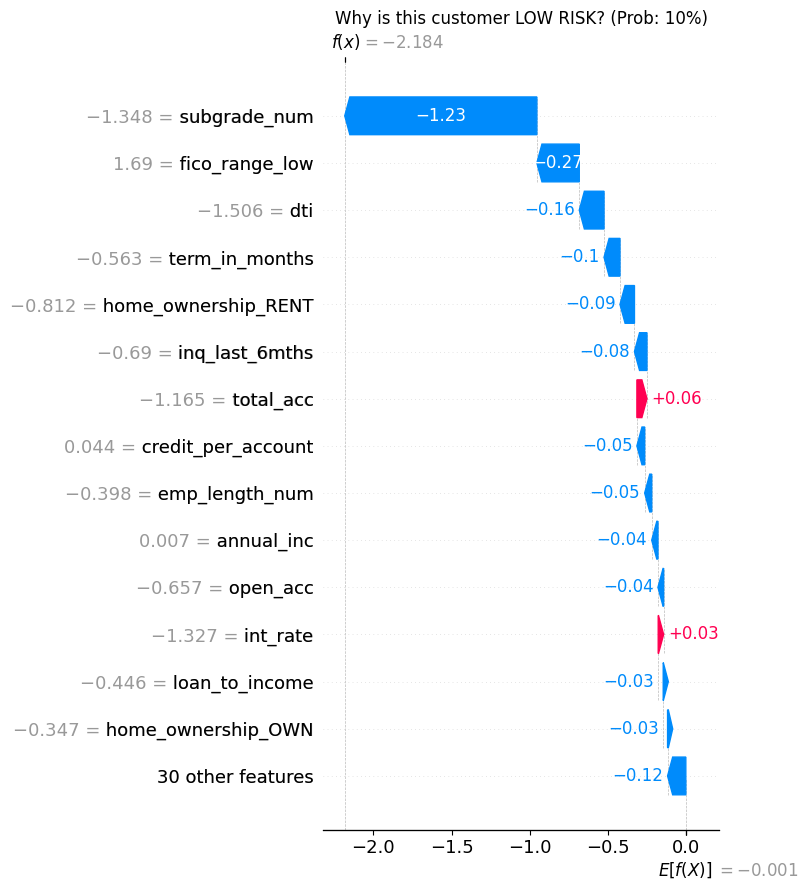

In [17]:
# INDIVIDUAL EXPLANATION - LOW RISK CUSTOMER
plt.figure(figsize=(10, 8))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[low_risk_idx],
    base_values=explainer.expected_value,
    data=X_sample_scaled[low_risk_idx],
    feature_names=features_name
), max_display=15, show=False)
plt.title(f"Why is this customer LOW RISK? (Prob: {proba[low_risk_idx]:.0%})", fontsize=12)
plt.tight_layout()
plt.show()


In [18]:
# EXPLANATION FUNCTION FOR PRODUCTION
def explain_prediction(input_data, model, scaler, explainer, feature_names, threshold=0.4):
    """
    Generate explanation for a single prediction.
    
    Args:
        input_data: Raw feature values (1D array)
        model: Trained XGBoost model
        scaler: Fitted StandardScaler
        explainer: SHAP TreeExplainer
        feature_names: List of feature names
        threshold: Decision threshold
    
    Returns:
        Dictionary with prediction details and explanations
    """
    # Scale input
    input_scaled = scaler.transform([input_data])
    
    # Get prediction probability
    proba = model.predict_proba(input_scaled)[0, 1]
    
    # Get SHAP values
    shap_vals = explainer.shap_values(input_scaled)[0]
    
    # Pair features with their SHAP values and sort by importance
    feature_impacts = list(zip(feature_names, shap_vals, input_data))
    feature_impacts.sort(key=lambda x: abs(x[1]), reverse=True)
    
    # Get top 5 risk factors and protective factors
    risk_factors = [(f, v, d) for f, v, d in feature_impacts if v > 0][:5]
    protective_factors = [(f, v, d) for f, v, d in feature_impacts if v < 0][:5]
    
    return {
        'probability': proba,
        'prediction': 'High Risk' if proba >= threshold else 'Low Risk',
        'risk_factors': risk_factors,
        'protective_factors': protective_factors
    }

print("Explanation function created!")


Explanation function created!


In [19]:
# TEST THE FUNCTION
test_customer = X_sample.iloc[high_risk_idx].values
result = explain_prediction(test_customer, model, scalar, explainer, features_name, threshold)

print("="*50)
print("PREDICTION RESULT")
print("="*50)
print(f"Risk Probability: {result['probability']:.2%}")
print(f"Decision: {result['prediction']}")

print("\n" + "="*50)
print("TOP RISK FACTORS (Increasing Risk)")
print("="*50)
for feature, shap_val, value in result['risk_factors']:
    print(f"  • {feature}: {shap_val:+.3f}")

print("\n" + "="*50)
print("PROTECTIVE FACTORS (Decreasing Risk)")
print("="*50)
for feature, shap_val, value in result['protective_factors']:
    print(f"  • {feature}: {shap_val:+.3f}")


PREDICTION RESULT
Risk Probability: 78.07%
Decision: High Risk

TOP RISK FACTORS (Increasing Risk)
  • subgrade_num: +0.737
  • term_in_months: +0.215
  • fico_range_low: +0.188
  • dti: +0.117
  • credit_history_months: +0.083

PROTECTIVE FACTORS (Decreasing Risk)
  • home_ownership_RENT: -0.133
  • loan_to_income: -0.054
  • total_acc: -0.034
  • annual_inc: -0.015
  • verification_status_Verified: -0.013


d:\AI Credit Risk Scoring + Explainable AI + LLM Layer\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
# SAVE SHAP EXPLAINER FOR STREAMLIT
with open('../models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("="*50)
print("ARTIFACTS SAVED")
print("="*50)
print("Saved: ../models/shap_explainer.pkl")
print("\nAll saved files:")
print("  • xgboost_model.pkl")
print("  • scaler.pkl")
print("  • feature_names.pkl")
print("  • threshold.pkl")
print("  • shap_explainer.pkl  ← NEW")


ARTIFACTS SAVED
Saved: ../models/shap_explainer.pkl

All saved files:
  • xgboost_model.pkl
  • scaler.pkl
  • feature_names.pkl
  • threshold.pkl
  • shap_explainer.pkl  ← NEW
